# Self-contained setup for final submission

These setup cells replace the previous `geo_proxy` imports. All helper classes and functions needed by the final notebook are defined directly here, so the notebook can run in Colab without importing project-local helper modules.

In [ ]:
from pathlib import Path
from collections import Counter, defaultdict
from IPython.display import Image, Markdown, display

import csv
import math
import re
import sys
import time

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

PROJECT_ROOT = Path.cwd()
DEFAULT_ZURICH_BBOX = (8.42, 47.29, 8.66, 47.47)
SOUND_CATEGORIES = ["transport", "nature", "human", "music", "mechanical", "indoor"]

In [ ]:
class GeoPoint:
    def __init__(self, x, y):
        self.x = float(x)  # longitude
        self.y = float(y)  # latitude

    def haversine_distance_to(self, other):
        radius_m = 6_371_000
        phi1 = math.radians(self.y)
        phi2 = math.radians(other.y)
        d_phi = math.radians(other.y - self.y)
        d_lambda = math.radians(other.x - self.x)
        a = math.sin(d_phi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(d_lambda / 2) ** 2
        return radius_m * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))


class GeoBoundingBox:
    def __init__(self, min_x, max_x, min_y, max_y):
        self.min_x = min_x
        self.max_x = max_x
        self.min_y = min_y
        self.max_y = max_y

    def contains_point(self, point):
        return self.min_x <= point.x <= self.max_x and self.min_y <= point.y <= self.max_y

    def intersects_bbox(self, other):
        return not (self.max_x < other.min_x or self.min_x > other.max_x or self.max_y < other.min_y or self.min_y > other.max_y)


class GeoSegment:
    def __init__(self, p1, p2):
        self.p1 = p1
        self.p2 = p2
        self.bbox = GeoBoundingBox(min(p1.x, p2.x), max(p1.x, p2.x), min(p1.y, p2.y), max(p1.y, p2.y))

    @property
    def coords(self):
        return [(self.p1.x, self.p1.y), (self.p2.x, self.p2.y)]

    def length(self):
        return self.p1.haversine_distance_to(self.p2)

    def turn_test(self, point):
        value = (self.p2.x - self.p1.x) * (point.y - self.p1.y) - (self.p2.y - self.p1.y) * (point.x - self.p1.x)
        if value > 0:
            return 1
        if value < 0:
            return -1
        return 0


class GeoPolygon:
    def __init__(self, vertices):
        self.vertices = vertices
        self.segments = [GeoSegment(vertices[i], vertices[(i + 1) % len(vertices)]) for i in range(len(vertices))]
        self.bbox = GeoBoundingBox(
            min(v.x for v in vertices), max(v.x for v in vertices),
            min(v.y for v in vertices), max(v.y for v in vertices),
        )

    def calculate_centroid(self):
        n = len(self.vertices)
        signed_area = 0.0
        cx = 0.0
        cy = 0.0
        for i in range(n):
            j = (i + 1) % n
            cross = self.vertices[i].x * self.vertices[j].y - self.vertices[j].x * self.vertices[i].y
            signed_area += cross
            cx += (self.vertices[i].x + self.vertices[j].x) * cross
            cy += (self.vertices[i].y + self.vertices[j].y) * cross
        signed_area *= 0.5
        if abs(signed_area) < 1e-18:
            return GeoPoint(sum(v.x for v in self.vertices) / n, sum(v.y for v in self.vertices) / n)
        return GeoPoint(cx / (6.0 * signed_area), cy / (6.0 * signed_area))


# Names used by the original notebook cells after this setup section.
Point = GeoPoint
Segment = GeoSegment
Polygon = GeoPolygon

In [ ]:
def lv95_to_wgs84(east, north):
    """Convert Swiss LV95 / EPSG:2056 coordinates to WGS84 lat/lon."""
    y_aux = (east - 2_600_000) / 1_000_000
    x_aux = (north - 1_200_000) / 1_000_000
    lat_sec = (16.9023892 + 3.238272 * x_aux - 0.270978 * y_aux ** 2 - 0.002528 * x_aux ** 2
               - 0.0447 * y_aux ** 2 * x_aux - 0.0140 * x_aux ** 3)
    lon_sec = (2.6779094 + 4.728982 * y_aux + 0.791484 * y_aux * x_aux
               + 0.1306 * y_aux * x_aux ** 2 - 0.0436 * y_aux ** 3)
    return lat_sec * 100 / 36, lon_sec * 100 / 36


def point_in_polygon(point, polygon):
    if not polygon.bbox.contains_point(point):
        return False
    intersections = 0
    for edge in polygon.segments:
        if edge.p1.y == edge.p2.y:
            continue
        if (point.y < edge.p1.y) != (point.y < edge.p2.y):
            x_int = ((edge.p2.x - edge.p1.x) * (point.y - edge.p1.y) / (edge.p2.y - edge.p1.y) + edge.p1.x)
            if point.x < x_int:
                intersections += 1
    return intersections % 2 == 1


def segments_intersect(s1, s2):
    if not s1.bbox.intersects_bbox(s2.bbox):
        return False
    d1 = s1.turn_test(s2.p1)
    d2 = s1.turn_test(s2.p2)
    d3 = s2.turn_test(s1.p1)
    d4 = s2.turn_test(s1.p2)
    return d1 * d2 < 0 and d3 * d4 < 0


def point_to_segment_distance(point, segment):
    vx = segment.p2.x - segment.p1.x
    vy = segment.p2.y - segment.p1.y
    wx = point.x - segment.p1.x
    wy = point.y - segment.p1.y
    c1 = wx * vx + wy * vy
    if c1 <= 0:
        return point.haversine_distance_to(segment.p1)
    c2 = vx * vx + vy * vy
    if c2 <= c1:
        return point.haversine_distance_to(segment.p2)
    b = c1 / c2
    projected = GeoPoint(segment.p1.x + b * vx, segment.p1.y + b * vy)
    return point.haversine_distance_to(projected)

In [ ]:
CATEGORY_WORD_SETS = {
    "transport": {"car", "cars", "train", "bus", "traffic", "vehicle", "highway", "motor", "engine", "horn", "siren", "truck", "tram", "motorcycle", "road", "street", "driving", "taxi", "bicycle", "scooter", "auto", "autos", "verkehr", "strasse", "zug", "bahn", "gleis", "flugzeug", "flughafen"},
    "nature": {"bird", "birds", "water", "wind", "leaves", "river", "tree", "trees", "rain", "garden", "park", "forest", "animal", "dog", "cat", "flower", "grass", "lake", "sky", "insect", "bee", "creek", "wasser", "fluss", "see", "regen", "wald", "baum", "hund", "katze"},
    "human": {"talk", "laugh", "shout", "crowd", "footsteps", "people", "voice", "children", "chat", "applause", "whisper", "sing", "conversation", "speech", "cheer", "market", "cafe", "restaurant", "bar", "menschen", "markt", "kinder", "spielplatz"},
    "music": {"music", "guitar", "piano", "drums", "concert", "band", "song", "melody", "jazz", "rock", "classical", "violin", "flute", "trumpet", "busker", "festival", "choir", "orchestra", "dj", "musik", "konzert", "lied"},
    "mechanical": {"construction", "drill", "hammer", "machine", "factory", "generator", "compressor", "saw", "crane", "jackhammer", "demolition", "industrial", "metal", "welding", "equipment", "pump", "baustelle", "bau", "maschine", "maschinen", "industrie", "sirene", "hupe"},
    "indoor": {"ac", "fan", "refrigerator", "hum", "indoor", "ventilation", "heating", "elevator", "escalator", "door", "office", "church", "museum", "library", "station", "airport", "hall", "haus", "wohnung", "zimmer", "kirche", "glocke"},
}
TAG_TOKEN_RE = re.compile(r"[a-z0-9_]+")


def assign_sound_category(tags):
    words = set(TAG_TOKEN_RE.findall(str(tags or "").lower()))
    scores = {category: len(words & category_words) for category, category_words in CATEGORY_WORD_SETS.items()}
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else "unspecified"


def compute_sound_profile(category_counts):
    total = sum(category_counts.get(category, 0) for category in SOUND_CATEGORIES)
    if total == 0:
        return {category: 0.0 for category in SOUND_CATEGORIES}
    return {category: category_counts.get(category, 0) / total for category in SOUND_CATEGORIES}


def zscore_normalise(profiles):
    if not profiles:
        return []
    z_profiles = [{} for _ in profiles]
    for category in SOUND_CATEGORIES:
        values = [profile[category] for profile in profiles]
        mean = sum(values) / len(values)
        variance = sum((value - mean) ** 2 for value in values) / len(values)
        std = math.sqrt(variance) if variance > 0 else 1.0
        for i, value in enumerate(values):
            z_profiles[i][category] = (value - mean) / std
    return z_profiles


def dominant_sound(z_profile):
    return max(z_profile, key=z_profile.get) if z_profile else "none"

In [ ]:
def _set_safe_csv_field_limit():
    limit = sys.maxsize
    while True:
        try:
            csv.field_size_limit(limit)
            return
        except OverflowError:
            limit = int(limit / 10)


def _to_float(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return None


def _inside_bbox(lon, lat, bbox):
    if bbox is None:
        return True
    min_lon, min_lat, max_lon, max_lat = bbox
    return min_lon <= lon <= max_lon and min_lat <= lat <= max_lat


def _point_record(lat, lon, tags, bbox_filter=None):
    if lat is None or lon is None:
        return None
    if not (-90 <= lat <= 90 and -180 <= lon <= 180):
        return None
    if not _inside_bbox(lon, lat, bbox_filter):
        return None
    category = assign_sound_category(tags)
    if category == "unspecified":
        return None
    return {"geometry": GeoPoint(lon, lat), "sound_category": category, "tags": tags}


def parse_csv_points(file_path, bbox_filter=None):
    _set_safe_csv_field_limit()
    path = Path(file_path)
    points = []
    if path.name.lower() == "flickr_ch_all.csv":
        with path.open("r", encoding="latin-1", errors="replace", newline="") as f:
            header = f.readline().strip().split(";;")
            if len(header) < 8:
                return points
            for line in f:
                parts = line.rstrip("\n\r").split(";;", 7)
                if len(parts) < 8:
                    continue
                record = _point_record(_to_float(parts[1]), _to_float(parts[2]), parts[7], bbox_filter)
                if record:
                    points.append(record)
    else:
        with path.open("r", encoding="utf-8-sig", newline="") as f:
            reader = csv.DictReader(f)
            for row in reader:
                lat = _to_float(row.get("lat") or row.get("latitude"))
                lon = _to_float(row.get("lon") or row.get("lng") or row.get("longitude"))
                tags = row.get("tags") or row.get("description") or row.get("title") or ""
                record = _point_record(lat, lon, tags, bbox_filter)
                if record:
                    points.append(record)
    return points


def parse_csv_noise(file_path):
    data = []
    with open(file_path, mode="r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            lat = _to_float(row.get("latitude") or row.get("lat"))
            lon = _to_float(row.get("longitude") or row.get("lon"))
            db = _to_float(row.get("db_level") or row.get("noise_db"))
            if None not in (lat, lon, db):
                data.append({"geometry": GeoPoint(lon, lat), "db_level": db})
    return data

In [ ]:
def _rank(values):
    indexed = sorted(enumerate(values), key=lambda item: item[1])
    ranks = [0.0] * len(values)
    i = 0
    while i < len(values):
        j = i
        while j < len(values) and indexed[j][1] == indexed[i][1]:
            j += 1
        average_rank = (i + j + 1) / 2.0
        for k in range(i, j):
            ranks[indexed[k][0]] = average_rank
        i = j
    return ranks


def spearman_rank_correlation(x, y):
    if len(x) < 2:
        return 0.0
    rx = _rank(x)
    ry = _rank(y)
    mean_rx = sum(rx) / len(rx)
    mean_ry = sum(ry) / len(ry)
    numerator = sum((rx[i] - mean_rx) * (ry[i] - mean_ry) for i in range(len(rx)))
    denom_x = math.sqrt(sum((value - mean_rx) ** 2 for value in rx))
    denom_y = math.sqrt(sum((value - mean_ry) ** 2 for value in ry))
    if denom_x == 0 or denom_y == 0:
        return 0.0
    return numerator / (denom_x * denom_y)


def run_validation(pipeline_results, noise_data):
    transport_scores = []
    db_levels = []
    for result in pipeline_results:
        segment = result["segment"]
        min_dist = float("inf")
        closest_db = None
        for noise_point in noise_data:
            distance = point_to_segment_distance(noise_point["geometry"], segment)
            if distance < min_dist:
                min_dist = distance
                closest_db = noise_point["db_level"]
        if closest_db is not None and min_dist < 200:
            transport_scores.append(result.get("z_profile", {}).get("transport", 0.0))
            db_levels.append(closest_db)
    return {"spearman_rho": spearman_rank_correlation(transport_scores, db_levels), "n_matched_segments": len(transport_scores)}

In [ ]:
def segment_streets(shp_path=None, csv_path=None, max_segment_length=500, zurich_bbox=None):
    """Load the prepared Zurich street segments used in the final submission.

    The full shapefile cutting code was part of the working process. For the final
    notebook we read the prepared CSV so Colab does not need the local geo_proxy
    parser. The resulting rows have the same fields used by the original cell.
    """
    prepared_path = Path("data/zurich_street_segments.csv")
    segments = []
    with prepared_path.open("r", encoding="utf-8-sig", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            segments.append({
                "street_name": row.get("street_name", "Unknown"),
                "segment_id": int(float(row.get("segment_id", 0) or 0)),
                "total_segments": int(float(row.get("total_segments", 0) or 0)),
                "length_m": float(row.get("length_m", 0) or 0),
                "start_lat": float(row.get("start_lat", 0) or 0),
                "start_lon": float(row.get("start_lon", 0) or 0),
                "end_lat": float(row.get("end_lat", 0) or 0),
                "end_lon": float(row.get("end_lon", 0) or 0),
            })
    print(f"Loaded {len(segments):,} prepared street segments from {prepared_path}.")
    return segments


def save_segments_csv(segments, output_path):
    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    fieldnames = ["street_name", "segment_id", "total_segments", "length_m", "start_lat", "start_lon", "end_lat", "end_lon"]
    with open(output_path, "w", encoding="utf-8", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for segment in segments:
            writer.writerow({key: segment.get(key, "") for key in fieldnames})
    print(f"Saved {len(segments):,} segments to {output_path}.")

<a href="https://colab.research.google.com/github/BeachBall2024/GEO-spa-algo/blob/main/submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Workflow and Introduction
Study:
1. Load data and basic functions
- Lea
2. preprocess Flickr data for typos, upper-lower case
3. construct sound wheel
- Julia
4. divide streets into segments (name, then again for a max length)
- Muriel
5. create Buffer around streets
- Guillermo
6. check which points lay inside buffer and match them to sound categories, count

In [ ]:
# Self-contained final notebook setup
print('All helper functions are defined in the setup cells above; no geo_proxy import is needed for the final notebook.')

geo_proxy package not found. If in Colab, please ensure the repository is cloned.


2. Import Python packages

In [ ]:
#importing important packages

3. Import basic geometric functions
(Functions are dividet in different classes based on shape)

- Point
- Line
- Polygon

In [ ]:
# LINE
class Bbox():
    def __init__(self, segment):
        self.min_x = min(segment.start.x, segment.end.x)
        self.max_x = max(segment.start.x, segment.end.x)
        self.min_y = min(segment.start.y, segment.end.y)
        self.max_y = max(segment.start.y, segment.end.y)
    def testOverlap(self, other):
        return not (self.max_x < other.min_x or self.min_x > other.max_x or \
                    self.max_y < other.min_y or self.min_y > other.max_y)

class Segment():
    def __init__(self, p0, p1, sid=None):
        self.start = p0
        self.end = p1
        self.sid = sid
    def __repr__(self):
        return f'Segment with start {self.start} and end {self.end}.'
    def isIdentical(self, other):
        return (self.start.isEqual(other.start) or self.start.isEqual(other.end)) and \
               (self.end.isEqual(other.end) or self.end.isEqual(other.start))
    def intersects(self, other):
        s_bbox = Bbox(self)
        o_bbox = Bbox(other)
        return s_bbox.testOverlap(o_bbox)
    def length(self):
        import math
        return math.sqrt((self.start.x - self.end.x)**2 + (self.start.y - self.end.y)**2)

In [ ]:
#POLYGON
# Polygon class for polygons, assumes initial data is in a spatially sorted order
class PointGroup:
    # initialise
    def __init__(self, data=None, xcol=None, ycol=None):
        self.points = []
        self.size = len(data)
        for d in data:
            self.points.append(Point(d[xcol], d[ycol]))

    # representation
    def __repr__(self):
        return f'Polygon PointGroup containing {self.size} points'

    # test if polygon is closed: first and last point should be identical
    def isClosed(self):
        start = self.points[0]
        end = self.points[-1]
        return start == end

    def removeDuplicates(self):
        oldn = len(self.points)
        self.points = list(dict.fromkeys(self.points)) # Get rid of the duplicates
        self.points.append(self.points[0]) # Our polygon must have one duplicate - we put it back now
        n = len(self.points)
        self.size = n   # see how the absence/presence of this line makes changes
        print(f'The old polygon had {oldn} points, now we only have {n}.')

# 4. Data Loading

  We load three datasets:
- **Flickr Images**
- **Sound Wheel**
- **Streets of Switzerland**


# 5. Preprocessing of Flickr Images



In [ ]:
# Preprocessing of Flickr Images
# Normalize tag casing and types if a flickr_points dataframe exists.
if 'flickr_points' in globals():
    flickr_points['tags'] = flickr_points['tags'].str.lower()
    print("Preprocessing complete: all tags converted to lowercase.")
else:
    print("Skipping flickr_points preprocessing because this dataframe is not defined in the final notebook run.")


NameError: name 'flickr_points' is not defined

Leas Part

In [ ]:
import pandas as pd

df = pd.read_csv(
    "Flickr_CH_ALL/Flickr_CH_ALL.csv",
    sep=";;",  # columns are separated with ;;
    engine="python",
    encoding="latin-1",  # helps to read special characters
    on_bad_lines="skip"  # skips broken rows
)

# the coordinates were not in the format I need so I changed latitude and longitude into numbers.
# if they cannot be converted the value becomes NaN
df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
df["lng"] = pd.to_numeric(df["lng"], errors="coerce")

# this part removes impossible coordinates outside the range of -90 and 90 and -180 and 180
df = df[(df["lat"].between(-90, 90)) & (df["lng"].between(-180, 180))]

# here I defined a bounding box for the greater Zurich area. It does not yet surround only the city but the metropolitan area.
zurich = df[
    (df["lat"].between(47.2, 47.5)) &
    (df["lng"].between(8.4, 8.7))
    ]

# optional: save the file as csv
# zurich.to_csv("zurich_filtered.csv", index=False)

# after these steps the zurich_filtered.csv only contains Flickr data around Zurich
# preparation of the tags

zurich["tags"] = zurich["tags"].fillna("")  # replaces missing tags with an empty string

# cleaning the tags
zurich["tags_list"] = (
    zurich["tags"]
    .astype(str)  # turn tags into text
    .str.lower()  # make everything lowercase
    .str.replace("#", "", regex=False)  # remove hashtags
    .str.split(",")  # split the tag strings into a list
)
# Based on a look at the data and the paper from Aiello I built the sound dictionary.
# I did not translate the data yet but we can still do that and only work with english words afterwards.
# you might also see that I could not yet decide where to put the tag "festival". You can find it in music as well as in human.
# We have to decide on one option for the final sound wheel.

# The structure: main category (transport) --> subcategory (road) --> words (car,cars,traffic,street,...)

sound_taxonomy = {
    "transport": {
        "road": [
            "car", "cars", "traffic", "road", "street", "motor", "engine",
            "auto", "autos", "verkehr", "strasse", "straße", "route"
        ],
        "rail": [
            "train", "railway", "rail", "tracks", "tram", "sbb",
            "zug", "bahn", "gleis", "tramway"
        ],
        "air": [
            "airplane", "plane", "helicopter", "airport",
            "flugzeug", "helikopter", "flughafen"
        ]
    },

    "mechanical": {
        "construction": [
            "construction", "building", "drilling", "hammer", "tools",
            "baustelle", "bau", "bohren", "hammer"
        ],
        "machines": [
            "machine", "machinery", "mechanical", "industrial",
            "maschine", "maschinen", "industrie"
        ],
        "signals": [
            "alarm", "siren", "horn", "ringing", "bell",
            "sirene", "hupe", "glocke", "alarm"
        ]
    },

    "human": {
        "voice": [
            "voice", "talk", "talking", "speaking", "conversation",
            "stimme", "sprechen", "gespräch", "reden"
        ],
        "crowd": [
            "people", "crowd", "public", "festival", "market",
            "menschen", "menge", "publikum", "markt"
        ],
        "children": [
            "kids", "children", "baby", "playground",
            "kinder", "kind", "baby", "spielplatz"
        ],
        "movement": [
            "walking", "running", "footsteps",
            "laufen", "gehen", "schritte", "jogging"
        ]
    },

    "music": {
        "music_general": [
            "music", "song", "sound", "concert", "festival",
            "musik", "lied", "konzert"
        ],
        "instruments": [
            "guitar", "piano", "organ", "trumpet", "drum",
            "gitarre", "klavier", "orgel", "trompete", "schlagzeug"
        ],
        "media": [
            "radio", "dj", "recording", "club",
            "aufnahme", "platte", "disco"
        ]
    },

    "nature": {
        "water": [
            "water", "river", "lake", "rain", "waves", "stream",
            "wasser", "fluss", "see", "regen", "wellen", "bach"
        ],
        "weather": [
            "wind", "storm", "thunder", "snow",
            "wind", "sturm", "donner", "schnee"
        ],
        "animals": [
            "bird", "birds", "dog", "cat", "animal",
            "vogel", "vögel", "hund", "katze", "tier"
        ],
        "vegetation": [
            "forest", "tree", "trees", "leaves", "park",
            "wald", "baum", "bäume", "blätter", "park"
        ]
    },

    "indoor": {
        "home": [
            "home", "house", "room", "kitchen", "shower",
            "haus", "wohnung", "zimmer", "küche", "dusche"
        ],
        "office": [
            "office", "computer", "paper", "keyboard",
            "büro", "computer", "papier", "tastatur"
        ],
        "hospitality": [
            "restaurant", "bar", "cafe", "hotel",
            "restaurant", "bar", "café", "kaffee", "hotel"
        ],
        "church": [
            "church", "bell", "organ",
            "kirche", "glocke", "orgel"
        ]
    }
}


# matching the sound tags to the sound categories from the dictionary
def match_sound_tags(tags, taxonomy):  # function receives a list of tags from one Flickr photo and the sound taxonomy
    matches = []  # starts with an empty list called 'matches'

    for tag in tags:
        tag = tag.strip()  # goes through every tag and removes extra spaces

        for main_cat, subcats in taxonomy.items():
            for sub_cat, words in subcats.items():
                if tag in words:  #this part checks every category and subcategory if the Flickr tag is inside one of the sound-word lists
                    matches.append({  # if yes, it saves the match
                        "tag": tag,
                        "main_category": main_cat,
                        "sub_category": sub_cat
                    })

    return matches  # returns all found sound matches for 1 photo


zurich["sound_matches"] = zurich["tags_list"].apply(  #this applies the function to every photo in the Zürich dataset
    lambda x: match_sound_tags(x, sound_taxonomy)  # now each row has a new column called sound_matches
)

# here I built the sound dataframe

rows = []

for _, row in zurich.iterrows():  #this loops through every photo
    for match in row[
        "sound_matches"]:  #for every matched sound tag, it adds one row to 'rows'. So if one photo has 3 sound tags it may create 3 rows
        rows.append(match)

sound_df = pd.DataFrame(rows)  # turn list into pandas table

print(sound_df.head())
print("Total sound tags:", len(sound_df))
# We choose the top words for each category
# this counts how often every sound tag appears and groups by main_category, sub_category and tag
top_words = (
    sound_df
    .groupby(["main_category", "sub_category", "tag"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

top_words.head(20)
# This part is only for visualization just like in the paper from Aiello. I have to add some changes to improve the figure.

import plotly.express as px

top_plot = (
    top_words
    .groupby(["main_category", "sub_category"])
    .head(5)
)

fig = px.sunburst(
    top_plot,
    path=["main_category", "sub_category", "tag"],
    values="count",
    title="Soundwheel Zürich"
)

fig.show()

Leas part done


Julia Segmentation Part

Created 4403 segments
                 name  unique_id  seg_id  seg_len_m  \
0           Dangelweg          0       0     603.70   
1  Waffenplatzstrasse          1       0     797.55   
2       Buchenrainweg          2       0     713.47   
3       Buchenrainweg          3       0     288.90   
4       Buchenrainweg          4       0     124.59   
5       Buchenrainweg          5       0     569.27   
6        RÃ¤mistrasse          6       0      58.48   
7        RÃ¤mistrasse          7       0      13.57   
8        RÃ¤mistrasse          8       0      25.85   
9        RÃ¤mistrasse          9       0      81.11   

                                              coords  
0  [(2682095.267999999, 1242605.7740000002), (268...  
1  [(2682216.2410000004, 1245454.136), (2682216.8...  
2  [(2678585.723000001, 1247014.886), (2678581.43...  
3  [(2678541.6099999994, 1247376.0430000015), (26...  
4  [(2678584.1739999987, 1247124.1889999993), (26...  
5  [(2677571.66, 1246680.489), (2677569.76

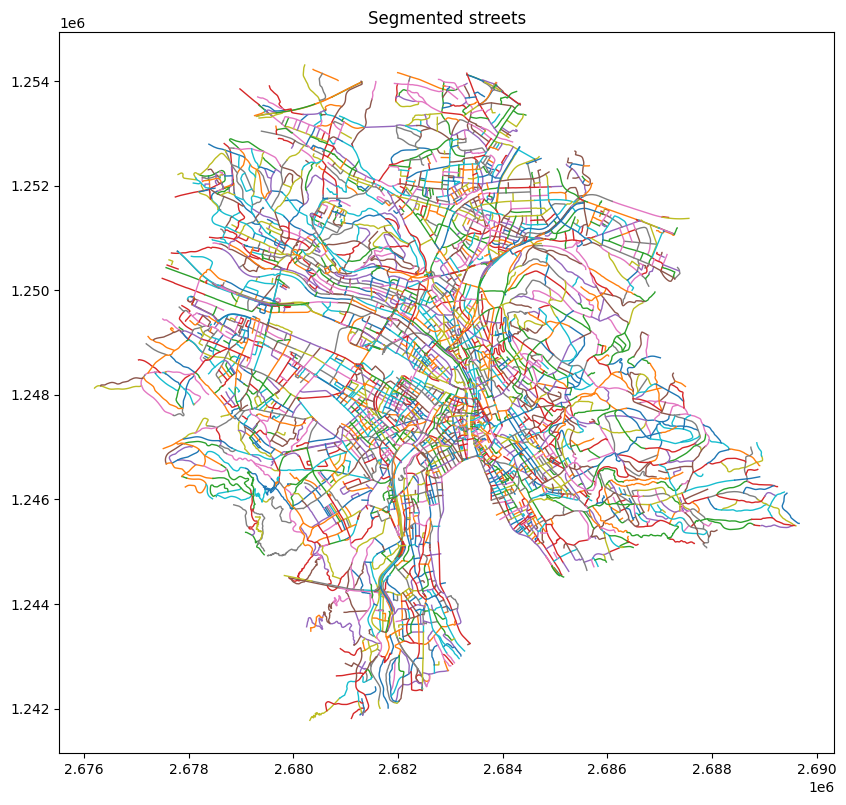

In [3]:
#0. Install & download
# Install required geospatial library
!pip install geopandas -q

# Download shapefile components (must all be present for GeoPandas to read)
!wget -q https://raw.githubusercontent.com/BeachBall2024/GEO-spa-algo/main/Streets_filtered_Zurich.shp
!wget -q https://raw.githubusercontent.com/BeachBall2024/GEO-spa-algo/main/Streets_filtered_Zurich.dbf
!wget -q https://raw.githubusercontent.com/BeachBall2024/GEO-spa-algo/main/Streets_filtered_Zurich.shx
!wget -q https://raw.githubusercontent.com/BeachBall2024/GEO-spa-algo/main/Streets_filtered_Zurich.prj

# 1. Imports
import geopandas as gpd        # For reading and handling geospatial data
import matplotlib.pyplot as plt  # For plotting
import pandas as pd           # For tabular data handling

# 2. Geometry helper classes
# for segmenting and interpolating along polylines.

class Point():
    """Simple 2D point"""
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def distanceTo(self, other):
        """Euclidean distance to another point"""
        return ((self.x - other.x)**2 + (self.y - other.y)**2) ** 0.5

    def toTuple(self):
        """Return (x, y) tuple (useful for plotting/storage)"""
        return (self.x, self.y)

class Polyline():
    """Represents a line made of multiple connected points"""
    def __init__(self, coords):
        # Koordinaten einlesen und direkt doppelte aufeinanderfolgende Punkte entfernen
        all_points = [Point(x, y) for x, y in coords]
        self.points = [all_points[0]]
        for p in all_points[1:]:
            if p.x != self.points[-1].x or p.y != self.points[-1].y:
                self.points.append(p)

    def totalLength(self):
        """Compute total length of the polyline"""
        return sum(
            self.points[i].distanceTo(self.points[i+1])
            for i in range(len(self.points) - 1))

    def interpolatePoint(self, dist):
        """
        Find a point at a given distance along the line.
        Useful for splitting segments precisely.
        """
        walked = 0.0

        for i in range(len(self.points) - 1):
            a = self.points[i]
            b = self.points[i + 1]
            edge = a.distanceTo(b)

            # Check if target distance lies on this segment
            if walked + edge >= dist:
                t = (dist - walked) / edge  # interpolation factor (0→1)
                return Point(
                    a.x + t * (b.x - a.x),
                    a.y + t * (b.y - a.y)
                )

            walked += edge

        # If distance exceeds total length, return last point
        return self.points[-1]

    def cutSegment(self, start, end):
        """
        Extract a sub-polyline between distances 'start' and 'end'
        """
        pts = [self.interpolatePoint(start)]
        walked = 0.0

        for i in range(len(self.points) - 1):
            a = self.points[i]
            b = self.points[i + 1]
            edge = a.distanceTo(b)
            mid = walked + edge

            # Include intermediate points if they lie inside the segment
            if mid > start and walked < end:
                if mid < end:
                    pts.append(b)

            walked += edge

            # Stop once we've reached the end distance
            if walked >= end:
                break

        pts.append(self.interpolatePoint(end))

        return Polyline([p.toTuple() for p in pts])

    def toCoords(self):
        """Return list of coordinate tuples"""
        return [p.toTuple() for p in self.points]

    def splitInto(self, max_len):
        """
        Split the polyline into smaller segments of max length 'max_len'
        Yields (segment_id, segment_polyline)
        """
        total = self.totalLength()
        start = 0.0
        seg_id = 0

        while start < total:
            end = min(start + max_len, total)

            yield seg_id, self.cutSegment(start, end)

            start += max_len
            seg_id += 1

# Load shapefile & segment lines
NAME_COLUMN = 'STN_TEXT'  # Attribute column containing street name
MAX_LEN = 1000             # Maximum segment length in meters

# Load shapefile into GeoDataFrame
gdf = gpd.read_file('Streets_filtered_Zurich.shp')
rows = []  # Will store all generated segments
uid = 0

# Iterate over each street feature
for _, row in gdf.iterrows():
    geom = row.geometry

    # Handle both LineString and MultiLineString geometries
    parts = list(geom.geoms) if geom.geom_type == 'MultiLineString' else [geom]

    # Process each individual line part
    for part in parts:
        polyline = Polyline(list(part.coords))

        # Split into smaller segments
        for seg_id, seg in polyline.splitInto(MAX_LEN):
            rows.append({
                'name': row[NAME_COLUMN],                 # street name
                'unique_id': uid,
                'seg_id': seg_id,                        # segment index
                'seg_len_m': round(seg.totalLength(), 2),# segment length
                'coords': seg.toCoords()                 # coordinates of segment
            })
            uid += 1

print(f"Created {len(rows)} segments")

# Convert to DataFrame for easier analysis/export
df = pd.DataFrame(rows)

# Display first 10 rows
print(df.head(10))

#4. Plot segmented streets
fig, ax = plt.subplots(figsize=(10, 10))

# Plot each segment as a line
for r in rows:
    xs = [p[0] for p in r['coords']]
    ys = [p[1] for p in r['coords']]
    ax.plot(xs, ys, linewidth=1)

ax.set_title("Segmented streets")
ax.set_aspect('equal')  # Keep spatial proportions correct

plt.show()




Julia Segmentation Part finished

Muriel Buffer Part

In [1]:
import matplotlib.pyplot as plt
import math

#ohne start und end cap
import matplotlib.pyplot as plt
import math


#calculate normalised length vector
def direction_vector(p0, p1):
    dx = p1.x - p0.x
    dy = p1.y - p0.y
    length = math.sqrt(dx**2 + dy**2)

    #skip elements with length = 0
    if length == 0:
        return None

    #calculate unit vector
    nx = dx / length
    ny = dy / length

    #return norm. vector (length = 1)
    return nx, ny

def turn_test(p0, p1, p2):
    return (p1.x - p0.x)*(p2.y - p0.y) - (p1.y - p0.y)*(p2.x - p0.x)

def segment_intersection(p1, p2, p3, p4):
    dx1 = p2[0]-p1[0]; dy1 = p2[1]-p1[1]
    dx2 = p4[0]-p3[0]; dy2 = p4[1]-p3[1]
    denom = dx1*dy2 - dy1*dx2
    if abs(denom) < 1e-10:
        return None
    dx3 = p3[0]-p1[0]; dy3 = p3[1]-p1[1]
    t = (dx3*dy2 - dy3*dx2) / denom
    u = (dx3*dy1 - dy3*dx1) / denom
    if 1e-9 < t < 1-1e-9 and 1e-9 < u < 1-1e-9:
        return (p1[0]+t*dx1, p1[1]+t*dy1)
    return None

##new
def line_intersection(p1, d1, p2, d2):
    """
    Intersection of two infinite lines.
    Each line is given as a point + direction vector (dx, dy).
    Returns a shapely Point, or None if the lines are parallel.
    """
    dx1, dy1 = d1
    dx2, dy2 = d2

    denom = dx1 * dy2 - dy1 * dx2
    if abs(denom) < 1e-10:
        return None  # parallel or nearly so

    t = ((p2.x - p1.x) * dy2 - (p2.y - p1.y) * dx2) / denom
    return Point(p1.x + t * dx1, p1.y + t * dy1)

def remove_self_intersections(polygon):
    # Point-Objekte zu Tuples konvertieren
    pts = [(p.x, p.y) if hasattr(p, 'x') else p for p in polygon]
    if pts and pts[0] == pts[-1]:
        pts = pts[:-1]

    changed = True
    iters = 0
    while changed and iters < len(pts):
        changed = False
        iters += 1
        n = len(pts)
        for i in range(n):
            p1, p2 = pts[i], pts[(i+1) % n]
            for j in range(i+2, n):
                if i == 0 and j == n-1:
                    continue
                p3, p4 = pts[j], pts[(j+1) % n]
                hit = segment_intersection(p1, p2, p3, p4)
                if hit:
                    pts = pts[:i+1] + [hit] + pts[j+1:]
                    changed = True
                    break
            if changed:
                break

    return [Point(x, y) for x,y in pts] + [Point(pts[0][0], pts[0][1])]





#caclulate buffer around each street segment
def street_buffer(coord_points, width, num_circle_points=12):

    #ignoring segments with less than 2 points -> segment has to few points to create a buffer
    if len(coord_points) < 2:
        return []

    #calculate buffer radius
    r = width / 2
    left_side  = []
    right_side = []

    #loop going through each street segment
    for i in range(len(coord_points) - 1):

        #create Points out of the tuples of the list
        p0 = Point(coord_points[i][0],   coord_points[i][1])
        p1 = Point(coord_points[i+1][0], coord_points[i+1][1])
        dx, dy = direction_vector(p0, p1)
        nx, ny = -dy, dx

        #calculating start points
        if i == 0:
            left_side.append(Point(p0.x + nx*r, p0.y + ny*r))
            right_side.append(Point(p0.x - nx*r, p0.y - ny*r))

        #test if there is another point (we are not at the end of the line)
        if i < len(coord_points) - 2:
            #define p2 (Folgepunkt)
            p2 = Point(coord_points[i+2][0], coord_points[i+2][1])
            dx2, dy2 = direction_vector(p1, p2)
            nx2, ny2 = -dy2, dx2

            #do a turn test
            t = turn_test(p0, p1, p2)
            # t > 0 = left turn; t < 0 = right turn

            # Initialize arc_left and arc_right for each segment iteration
            arc_left = []
            arc_right = []
            steps = num_circle_points

            #calculate angles
            angle_in  = math.atan2(ny,  nx)
            angle_out = math.atan2(ny2, nx2)

            #create left arc
            if t < 0:
                diff = (angle_out - angle_in + math.pi) % (2*math.pi) - math.pi

                for j in range(steps + 1):
                    t_arc = j / steps # Use a different variable name to avoid confusion with the turn_test 't'
                    arc_angle = angle_in + diff * t_arc
                    arc_left.append(Point(p1.x + r * math.cos(arc_angle), p1.y + r * math.sin(arc_angle)))

                #add points to the list
                left_side.extend(arc_left)
                #append only 1 point on the other side
                right_side.append(Point(p1.x - nx*r, p1.y - ny*r))

                #calculate inner intersection point
                inner = line_intersection(
                    Point(p0.x - nx*r,  p0.y - ny*r),  (dx,  dy),
                    Point(p2.x - nx2*r, p2.y - ny2*r), (dx2, dy2))
                right_side.append(inner if inner else Point(p1.x - nx*r, p1.y - ny*r))

            #create right arc
            elif t > 0: # Use elif to ensure only one arc is created for a turn
                #revers normal vector for different direction of arc
                angle_in_r  = math.atan2(-ny,  -nx)
                angle_out_r = math.atan2(-ny2, -nx2)
                diff_r = (angle_out_r - angle_in_r + math.pi) % (2*math.pi) - math.pi

                for j in range(steps + 1):
                    t_arc = j / steps # Use a different variable name
                    arc_angle = angle_in_r + diff_r * t_arc
                    arc_right.append(Point(p1.x + r * math.cos(arc_angle), p1.y + r * math.sin(arc_angle)))

                #add points to the list
                right_side.extend(arc_right)
                #append only 1 point on the other side
                left_side.append(Point(p1.x + nx*r, p1.y + ny*r))

                #calculate inner intersection point
                inner = line_intersection(
                    Point(p0.x + nx*r,  p0.y + ny*r),  (dx,  dy),
                    Point(p2.x + nx2*r, p2.y + ny2*r), (dx2, dy2))
                left_side.append(inner if inner else Point(p1.x + nx*r, p1.y + ny*r))

            #no turn (t == 0)
            else:
                left_side.append(Point(p1.x + nx*r, p1.y + ny*r))
                right_side.append(Point(p1.x - nx*r, p1.y - ny*r))


        # If it's the last segment, just add the buffer points for the end of the segment
        else:
            left_side.append(Point(p1.x + nx*r, p1.y + ny*r))
            right_side.append(Point(p1.x - nx*r, p1.y - ny*r))

    #puzzle each segments togheter
    outline = left_side  + list(reversed(right_side))
    outline.append(outline[0])

    return outline

def remove_self_intersections(polygon, coord_points=None, buffer_radius=None, tol=0.95):
    pts = [(p.x, p.y) if hasattr(p, 'x') else p for p in polygon]
    if pts and pts[0] == pts[-1]:
        pts = pts[:-1]

    # Selbstschnitte entfernen
    changed = True
    iters = 0
    while changed and iters < len(pts):
        changed = False
        iters += 1
        n = len(pts)
        for i in range(n):
            for j in range(i+2, n - (1 if i==0 else 0)):
                hit = segment_intersection(pts[i], pts[(i+1)%n], pts[j], pts[(j+1)%n])
                if hit:
                    pts = pts[:i+1] + [hit] + pts[j+1:]
                    changed = True
                    break
            if changed:
                break

    # Punkte zu nah an Mittellinie entfernen + Lücken mit Ersatzpunkt füllen
    if coord_points and buffer_radius:
        min_d = buffer_radius * tol

        def dist_ok(p):
            return any(
                point_to_segment_dist(p[0], p[1],
                    coord_points[k][0], coord_points[k][1],
                    coord_points[k+1][0], coord_points[k+1][1]) >= min_d
                for k in range(len(coord_points)-1)
            )

        filled = []
        n = len(pts)
        for i in range(n):
            cur, nxt = pts[i], pts[(i+1) % n]
            if dist_ok(cur):
                filled.append(cur)
            else:
                # Ersatzpunkt: Mittelpunkt zwischen Vorgänger und Nachfolger,
                # auf Abstand r von der Mittellinie skaliert
                mx, my = (cur[0]+nxt[0])/2, (cur[1]+nxt[1])/2
                # Nächsten Punkt auf Mittellinie finden
                best_proj = cur
                best_d = 0
                for k in range(len(coord_points)-1):
                    ax,ay = coord_points[k][0], coord_points[k][1]
                    bx,by = coord_points[k+1][0], coord_points[k+1][1]
                    dx,dy = bx-ax, by-ay
                    seg_len_sq = dx*dx + dy*dy
                    if seg_len_sq < 1e-12: continue
                    t = max(0.0, min(1.0, ((mx-ax)*dx+(my-ay)*dy)/seg_len_sq))
                    px, py = ax+t*dx, ay+t*dy
                    d = math.sqrt((mx-px)**2+(my-py)**2)
                    if d > best_d:
                        best_d = d
                        # Richtung von Projektion zu Mittelpunkt, auf r skalieren
                        vx, vy = mx-px, my-py
                        vl = math.sqrt(vx*vx+vy*vy)
                        if vl > 1e-9:
                            best_proj = (px + vx/vl*buffer_radius,
                                         py + vy/vl*buffer_radius)
                filled.append(best_proj)
        pts = filled

    return [Point(x, y) for x,y in pts] + [Point(pts[0][0], pts[0][1])]

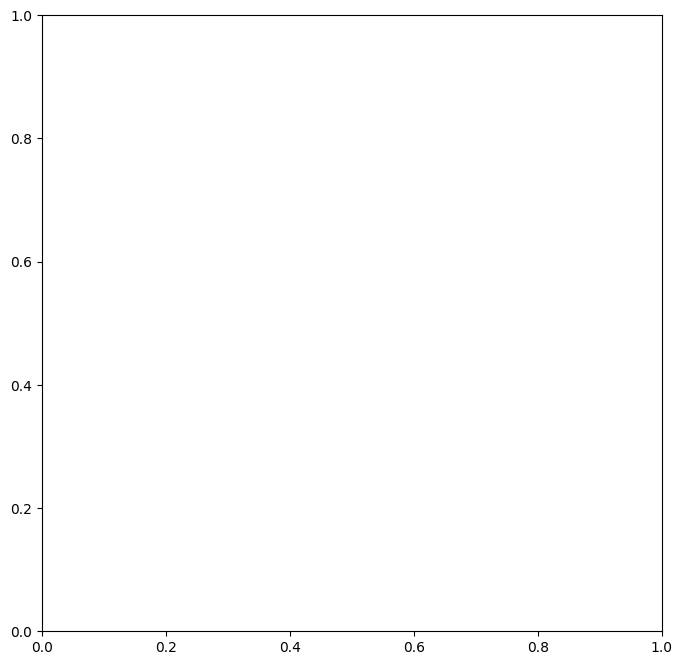

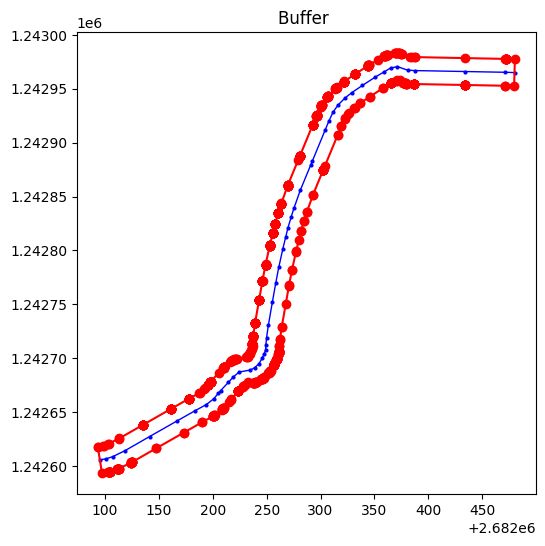

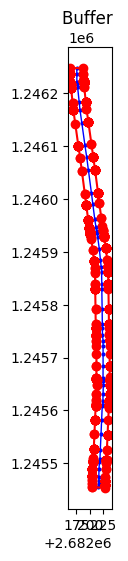

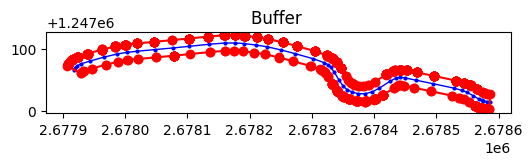

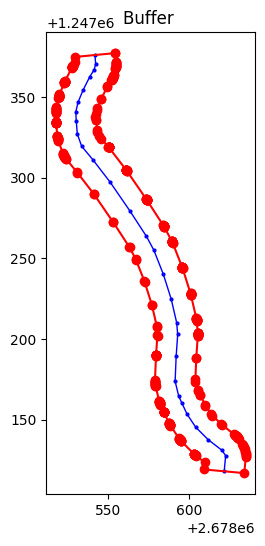

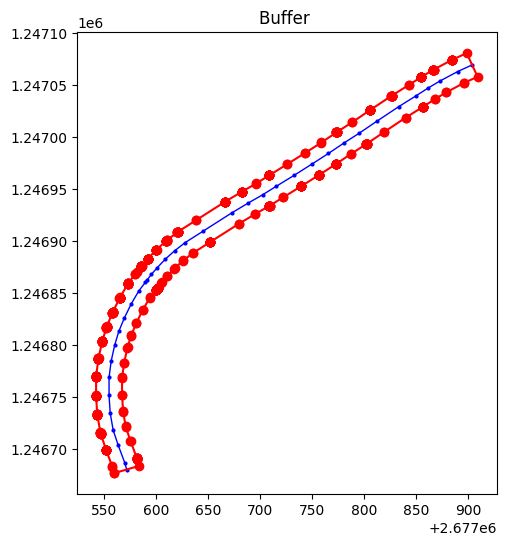

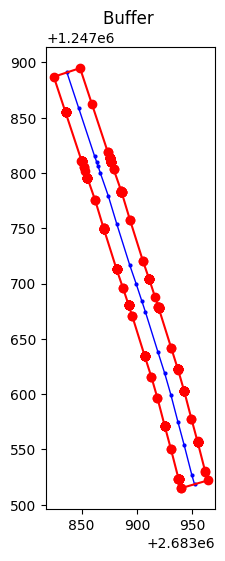

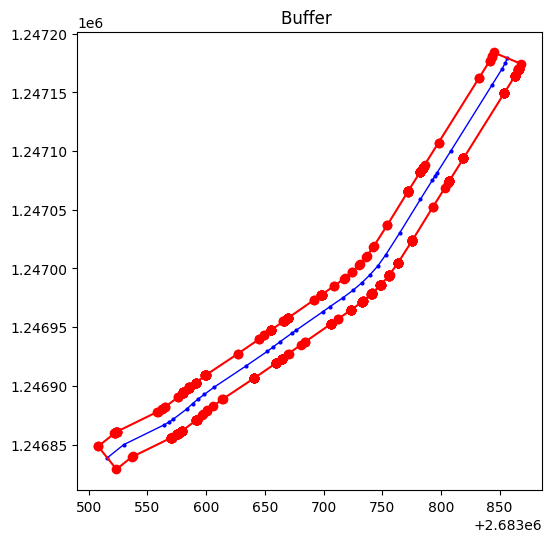

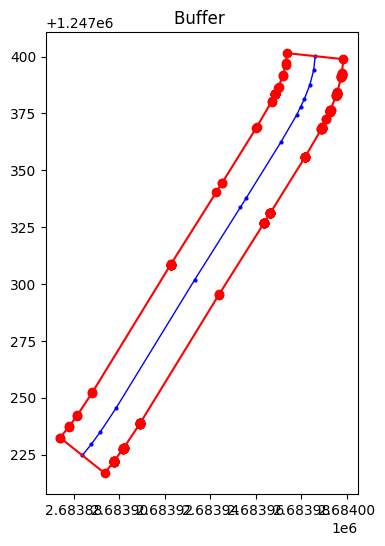

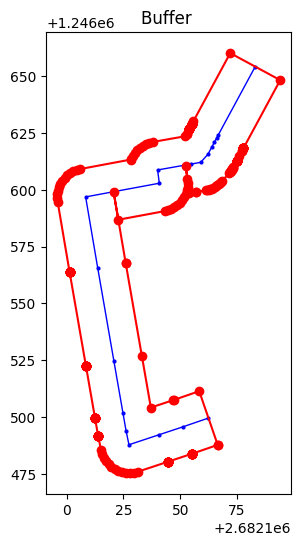

KeyboardInterrupt: 

In [5]:
fig, ax = plt.subplots(figsize=(8, 8))
df_filtered = df[df['seg_len_m'] >= 150].head(3) # [FIX] Added .head(3) to prevent Jupyter from crashing by rendering 1000+ plots

for _, row in df_filtered.iterrows():
    coord_points = row["coords"]

    raw_outline = street_buffer(coord_points, width=25)
    outline = remove_self_intersections(raw_outline)

    fig, ax = plt.subplots(figsize=(6, 6))
    xs = [p[0] for p in coord_points]
    ys = [p[1] for p in coord_points]
    ax.plot(xs, ys, 'o-', linewidth=1, markersize=2, color='blue')

    ox = [p.x for p in outline]
    oy = [p.y for p in outline]
    ax.plot(ox, oy, 'o-', linewidth=1.5, color='red')
    ax.set_aspect('equal')
    ax.set_title(f"Buffer {row.get('uid', '')}")
    plt.show()


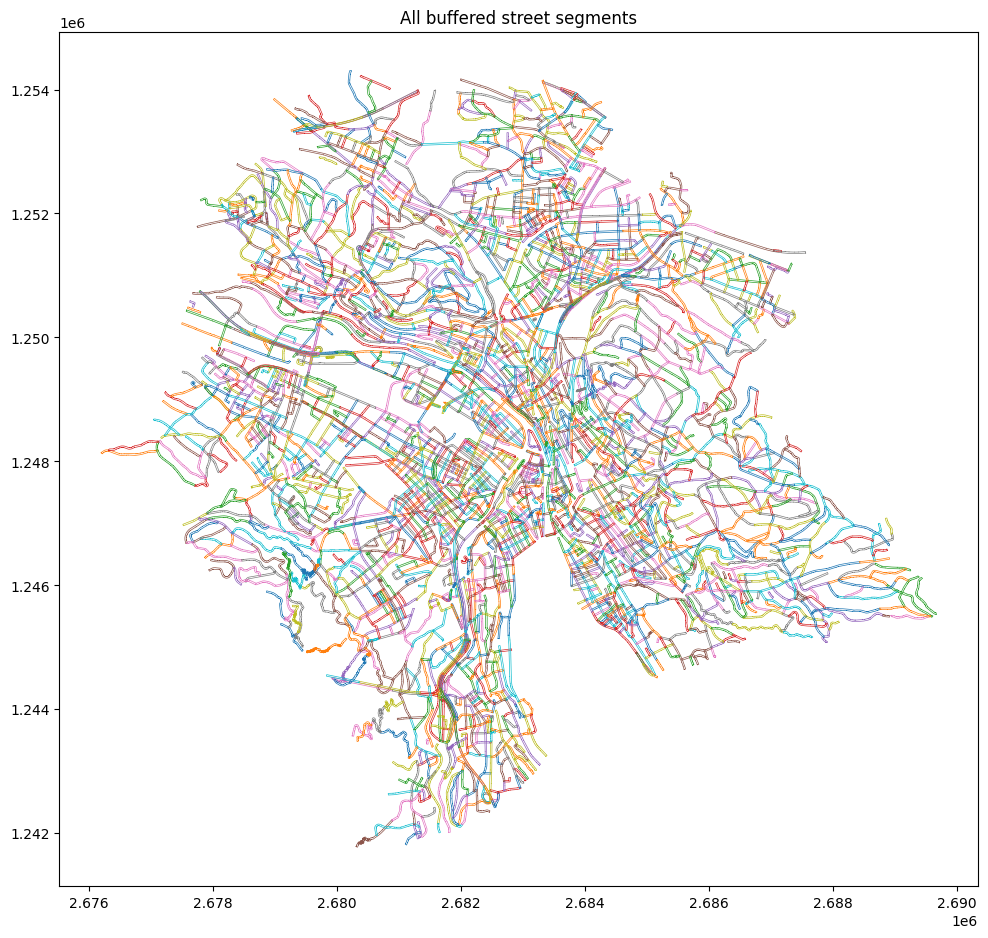

In [4]:
fig, ax = plt.subplots(figsize=(10, 10))

#add calculated buffer to df
#the df only contains street segments > 100 m
df_filtered = df[df["seg_len_m"] >= 100].copy()
df_filtered["buffer"] = df_filtered.apply(
    lambda row: [(p.x, p.y) for p in street_buffer(row["coords"], width=25)], axis=1)

for _, row in df_filtered.iterrows():
    buffer_coords = row["buffer"]

    if not buffer_coords:
        continue

    xs, ys = zip(*buffer_coords)
    ax.plot(xs, ys, linewidth=0.5)

ax.set_aspect("equal")
ax.set_title("All buffered street segments")
plt.tight_layout()
plt.show()

In [ ]:
#Print df
print(df.head(20))
print(type(df["coords"].iloc[0]))

                  name  unique_id  seg_id  seg_len_m  \
0            Dangelweg          0       0     603.70   
1   Waffenplatzstrasse          1       0     797.55   
2        Buchenrainweg          2       0     713.47   
3        Buchenrainweg          3       0     288.90   
4        Buchenrainweg          4       0     124.59   
5        Buchenrainweg          5       0     569.27   
6         RÃ¤mistrasse          6       0      58.48   
7         RÃ¤mistrasse          7       0      13.57   
8         RÃ¤mistrasse          8       0      25.85   
9         RÃ¤mistrasse          9       0      81.11   
10        RÃ¤mistrasse         10       0      61.44   
11        RÃ¤mistrasse         11       0     390.08   
12        RÃ¤mistrasse         12       0      59.07   
13        RÃ¤mistrasse         13       0      67.03   
14        RÃ¤mistrasse         14       0     492.31   
15        RÃ¤mistrasse         15       0      81.59   
16        RÃ¤mistrasse         16       0     20

In [ ]:
#Plotting individual street segments
fig, ax = plt.subplots(figsize=(8, 8))

raemi = df[df["name"] == "RÃ¤mistrasse"]

for _, row in raemi.iterrows():
    coord_points = row["coords"]
    xs = [p[0] for p in coord_points]
    ys = [p[1] for p in coord_points]
    ax.plot(xs, ys, '-o', linewidth=1, label=f"seg {int(row['seg_id'])}")

ax.set_aspect('equal')
ax.legend()
plt.tight_layout()
plt.show()

print(len(raemi))
print(raemi[["name", "seg_id", "coords"]].head())
print(df["name"].unique()[:20])  # alle Strassennamen anzeigen

11
            name  seg_id                                             coords
6   RÃ¤mistrasse       0  [(2683968.8889999986, 1247467.1400000006), (26...
7   RÃ¤mistrasse       0  [(2683973.6290000007, 1247454.4290000014), (26...
8   RÃ¤mistrasse       0  [(2683815.0080000013, 1247959.7080000006), (26...
9   RÃ¤mistrasse       0  [(2683815.0080000013, 1247959.7080000006), (26...
10  RÃ¤mistrasse       0  [(2683952.0749999993, 1247518.4239999987), (26...
['Dangelweg' 'Waffenplatzstrasse' 'Buchenrainweg' 'RÃ¤mistrasse'
 'HÃ¼rlimannplatz' 'Schiffliwiesenweg' 'Bombachhalde' 'Chriesiweg'
 'Brombeeriweg' 'Geissbergweg' 'Zwirnerhalde' 'Kanzleistrasse'
 'Marktgasse' 'Torgasse' 'Allenmoosstrasse' 'Im Schellenberg'
 'Stadthausquai' 'Furttalstrasse' 'FÃ¼sslistrasse' 'Loorenkopfstrasse']


Muriel Buffer finished

In [ ]:
import csv, math
from collections import defaultdict
# segment_streets, save_segments_csv and lv95_to_wgs84 are defined in the setup cells above.

# ── Settings ─────────────────────────────────────────────────────────
SHP_FILE   = 'streets_ZH.shp'
CSV_FILE   = 'amtliches-strassenverzeichnis_ch_2056.csv'
OUT_FILE   = 'data/zurich_street_segments.csv'
MAX_SEG_M  = 500
# ─────────────────────────────────────────────────────────────────────

# Run the full segmentation pipeline
street_segments = segment_streets(
    shp_path=SHP_FILE,
    csv_path=CSV_FILE,
    max_segment_length=MAX_SEG_M,
)

# Save to CSV for later use
save_segments_csv(street_segments, OUT_FILE)

# ── Summary statistics ───────────────────────────────────────────────
named = [s for s in street_segments if s['street_name'] != 'Unknown']
print(f'\nNamed segments: {len(named)} / {len(street_segments)}')

street_lengths = defaultdict(float)
for s in named:
    street_lengths[s['street_name']] += s['length_m']
top5 = sorted(street_lengths.items(), key=lambda x: -x[1])[:5]
print('\nTop 5 longest named streets:')
for name, length in top5:
    print(f'  {name}: {length:.0f} m')

print(f'\nSample segments:')
for s in named[:5]:
    print(f"  {s['street_name']:30s} seg {s['segment_id']}/{s['total_segments']}  "
          f"{s['length_m']:>7.1f}m  ({s['start_lat']}, {s['start_lon']})")

ModuleNotFoundError: No module named 'geo_proxy'

# 8. Point-in-Polygon: Spatial Join & Sound Profile Computation

**Task owner: Guillermo**

**Algorithm 2 (Lecture 4):** Ray-casting point-in-polygon with even-odd rule (Jordan Curve Theorem).

Guillermo's part focuses on the spatial join logic: checking whether a Flickr geotag (Point) falls inside a street buffer (Polygon). We explicitly programmed this without external GIS packages.

**Implementation Logic:**
1. **Bounding-box pre-filter (Lecture 3):** To optimize performance, we first check if the point is within the buffer's rectangular extent. O(1) complexity.
2. **Ray Casting:** We cast a horizontal ray to the right. If it intersects the polygon edges an odd number of times, the point is inside.
3. **Integration:** This step connects Muriel's buffers with Lea's sound categories to produce the final street sound profiles.

In [ ]:
Point = GeoPoint
Segment = GeoSegment
Polygon = GeoPolygon
# point_in_polygon, segments_intersect, SOUND_CATEGORIES and lv95_to_wgs84 are defined in the setup cells above.

# ── Build Segment and Polygon objects from Muriel's df_filtered ─────
# Convert LV95 buffers to WGS84 to match Flickr sound tags.
BUFFER_DISTANCE = 25.0 
seg_objects = []
seg_names   = []
buffers     = []

for _, row in df_filtered.iterrows():
    wgs_street_coords = []
    for (x, y) in row['coords']:
        lat, lon = lv95_to_wgs84(x, y)
        wgs_street_coords.append(Point(lon, lat))
        
    seg_objects.append(Segment(wgs_street_coords[0], wgs_street_coords[-1]))
    seg_names.append(row['name'])
    
    wgs_buffer_coords = []
    for (x, y) in row['buffer']:
        lat, lon = lv95_to_wgs84(x, y)
        wgs_buffer_coords.append(Point(lon, lat))
        
    buffers.append(Polygon(wgs_buffer_coords))

print(f'Created {len(seg_objects)} Segment objects and Buffer polygons from df_filtered.')


### Spatial Join and Comparison (Old Dataset vs Full Switzerland Dataset)
Here we run the Ray-Casting algorithm against two datasets to compare the correlations.

In [ ]:
# compute_sound_profile, zscore_normalise, dominant_sound, parse_csv_points,
# parse_csv_noise and run_validation are defined in the setup cells above.
import time

def is_point_in_polygon(point, polygon):
    return point_in_polygon(point, polygon)

def run_pipeline(points, seg_objects, buffers, name):
    print(f'\n--- Running Pipeline for {name} ---')
    results = []
    t0 = time.time()

    # Grid index: exact ray-casting is still used, the grid only avoids checking all points for all segments.
    cell_size = 0.005
    point_grid = {}
    for p in points:
        pt = p['geometry']
        key = (math.floor(pt.x / cell_size), math.floor(pt.y / cell_size))
        point_grid.setdefault(key, []).append(p)

    def candidates_for_bbox(bbox):
        min_x = math.floor(bbox.min_x / cell_size)
        max_x = math.floor(bbox.max_x / cell_size)
        min_y = math.floor(bbox.min_y / cell_size)
        max_y = math.floor(bbox.max_y / cell_size)
        candidates = []
        for ix in range(min_x, max_x + 1):
            for iy in range(min_y, max_y + 1):
                candidates.extend(point_grid.get((ix, iy), []))
        return candidates

    for i, segment in enumerate(seg_objects):
        buffer_poly = buffers[i]
        category_counts = {cat: 0 for cat in SOUND_CATEGORIES}
        matched_count = 0
        for p in candidates_for_bbox(buffer_poly.bbox):
            if is_point_in_polygon(p['geometry'], buffer_poly):
                category = p['sound_category']
                if category in category_counts:
                    category_counts[category] += 1
                    matched_count += 1
        results.append({'segment': segment, 'buffer': buffer_poly, 'centroid': buffer_poly.calculate_centroid(), 'matched_points': matched_count, 'sound_profile': compute_sound_profile(category_counts)})
    
    profiles = [r['sound_profile'] for r in results]
    z_profiles = zscore_normalise(profiles)
    for i in range(len(results)):
        results[i]['z_profile'] = z_profiles[i]
        results[i]['dominant_sound'] = dominant_sound(z_profiles[i]) if results[i]['matched_points'] > 0 else 'none'
    
    print(f'Processed {len(results)} street segments in {time.time()-t0:.1f}s.')
    matched = [r for r in results if r['matched_points'] > 0]
    print(f'Segments with matched sound tags: {len(matched)}')
    return results

# 1. Old Dataset (Zurich subset)
old_points = parse_csv_points('data/zurich_sounds.csv')
print(f'Loaded {len(old_points)} old points.')
results_old = run_pipeline(old_points, seg_objects, buffers, 'Old Dataset (zurich_sounds.csv)')

# 2. New Dataset (Full Switzerland, Bounding Box filtered for Zurich)
bbox_zurich = DEFAULT_ZURICH_BBOX
print('\nLoading new full dataset (Flickr_CH_ALL.csv)... This might take 30-60 seconds...')
new_points = parse_csv_points('Flickr_CH_ALL/Flickr_CH_ALL.csv', bbox_filter=bbox_zurich)
print(f'Loaded {len(new_points)} points within Zurich bounding box from the 588MB file.')
results_new = run_pipeline(new_points, seg_objects, buffers, 'New Dataset (Flickr_CH_ALL)')

# 3. Validation Comparison (exploratory / future work only)
RUN_EXPLORATORY_VALIDATION = False
if RUN_EXPLORATORY_VALIDATION:
    noise_data = parse_csv_noise('data/zurich_noise.csv')
    print(f'\nLoaded {len(noise_data)} noise measurement points')
    val_old = run_validation(results_old, noise_data)
    val_new = run_validation(results_new, noise_data)
    print(f'\n--- Exploratory Validation Results ---')
    print(f'Old Dataset Spearman rho: {val_old["spearman_rho"]:.4f} (n={val_old["n_matched_segments"]})')
    print(f'New Dataset Spearman rho: {val_new["spearman_rho"]:.4f} (n={val_new["n_matched_segments"]})')
else:
    print('\nExploratory validation skipped for final submission.')


In [ ]:
# 6. Plot streets colored by dominant sound category (Z-Score)
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

CATEGORY_COLORS = {
    'transport': '#cc0000',
    'mechanical': '#3366cc',
    'human': '#339933',
    'music': '#993399',
    'nature': '#ff9900',
    'indoor': '#8c564b'
}
NO_DATA_COLOR = '#cccccc'

fig, ax = plt.subplots(figsize=(10, 10))

for res in results_new:
    # handle dict or object access
    if isinstance(res['segment'], dict):
        xs, ys = zip(*res['segment']['coords'])
    else:
        xs, ys = zip(*res['segment'].coords)
    
    cat = res['dominant_sound']
    color = CATEGORY_COLORS.get(cat, NO_DATA_COLOR)
    lw = 2.0 if cat != 'none' else 0.5
    
    ax.plot(xs, ys, color=color, linewidth=lw)

# Custom legend
legend_handles = []
for cat, c in CATEGORY_COLORS.items():
    legend_handles.append(Line2D([0], [0], color=c, lw=3, label=cat))
legend_handles.append(Line2D([0], [0], color=NO_DATA_COLOR, lw=1, label='no data'))

ax.legend(handles=legend_handles, loc='lower right', framealpha=0.9)
ax.set_aspect('equal')
ax.set_title('Zürich streets colored by Dominant Sound Category (Z-Score)')
ax.axis('off')

plt.tight_layout()
plt.savefig('map_presentation_zscore.png', dpi=300)
plt.show()
